# 🧠 Processamento de Linguagem Natural (NLP) e Análise de Sentimentos

Iniciamos o pipeline de engenharia de linguagem natural realizando o diagnóstico estrutural e carregamento da base de dados textuais para o desenvolvimento de modelos de classificação:

* **Ingestão de Dados Textuais Não Estruturados:** Leitura sistemática do arquivo `Dados/dataset_avaliacoes.csv` utilizando o ecossistema Pandas para estruturação em um DataFrame bidimensional.
* **Auditoria de Escopo e Balanceamento de Classes:** Análise preliminar da volumetria, detecção de dados nulos nas strings e avaliação de balanceamento das variáveis-alvo (polaridades positiva e negativa) para mitigar vieses algorítmicos durante o treinamento.


In [33]:
import pandas as pd


In [34]:
# 1. Lê o arquivo usando a barra correta para sumir com o aviso de SyntaxWarning
df = pd.read_csv("Dados/dataset_avaliacoes.csv")

# 2. Exibe as 5 primeiras linhas do seu conjunto de dados na tela
df.head()


,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


In [35]:
df.shape

(15501, 4)

In [36]:
# Mostra a contagem absoluta de linhas por sentimento
df['sentimento'].value_counts()


sentimento
positivo    7890
negativo    7611
Name: count, dtype: int64

In [37]:
df['sentimento'].value_counts('sentimento')

sentimento
positivo    0.508999
negativo    0.491001
Name: proportion, dtype: float64

In [38]:
print('positiva \n')

df.avaliacao[0]

positiva 



'Esse smartphone superou minhas expectativas, recomendo'

In [39]:
print('negativa \n')

df.avaliacao[2]

negativa 



'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.'

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

texto = ['Comprei um produto ótimo', 'Comprei um produto ruim']

vetorizar = CountVectorizer()
bag_of_words = vetorizar.fit_transform(texto)

In [41]:
bag_of_words

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (2, 5)>

In [42]:
import pandas as pd

matriz_esparsa = pd.DataFrame.sparse.from_spmatrix(
    bag_of_words,
    columns=vetorizar.get_feature_names_out()
)

In [43]:
matriz_esparsa

,comprei,produto,ruim,um,ótimo
0,1,1,0,1,1
1,1,1,1,1,0


In [44]:
vetorizar = CountVectorizer(lowercase=False, max_features=50)
bag_of_words = vetorizar.fit_transform(df.avaliacao)
print(bag_of_words.shape)

(15501, 50)


In [45]:
matriz_esparsa_avaliacoes = pd.DataFrame.sparse.from_spmatrix(
    bag_of_words,
    columns=vetorizar.get_feature_names_out()
)

In [46]:
matriz_esparsa_avaliacoes

,Não,Produto,ainda,antes,as,até,bem,bom,chegou,com,...,qualidade,que,recebi,recomendo,se,sem,tem,um,uma,veio
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,1,2,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
15497,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
15498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
15499,0,1,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


## 🧠 Engenharia de Recursos: Engenharia de Recursos com Bag of Words (BOW)

A técnica **Bag of Words** (Saco de Palavras) converte textos não estruturados em vetores numéricos estruturados para alimentar modelos de aprendizado de máquina. Esse processo ignora a ordem sintática e o contexto gramatical, focando estritamente na frequência volumétrica e na presença dos termos dentro de um dicionário global (corpus).

### 📋 Fluxo de Processamento Logístico:
1. **Mapeamento do Vocabulário:** Varredura completa do corpus textual para isolar e registrar todas as palavras únicas.
2. **Vetorização Esparsa:** Criação de matrizes booleanas ou de contagem, onde cada linha representa um documento e cada coluna representa um token (palavra).
3. **Mapeamento Binário:** Preenchimento de bits (`1` para presença do termo na instância, `0` para ausência).

> **Vantagem:** Simplicidade de implementação, alta interpretabilidade estatística e processamento rápido.
> **Limitação:** Perda completa do contexto e da semântica original (a ordem das palavras é totalmente descartada).


In [47]:
from sklearn.model_selection import train_test_split

x_treino, x_test, y_treino, y_test = train_test_split(bag_of_words, df.sentimento, random_state=4978)

In [48]:
from sklearn.linear_model import LogisticRegression

regressao_logistica = LogisticRegression()
regressao_logistica.fit(x_treino, y_treino)
acuracia = regressao_logistica.score(x_test, y_test)
print(acuracia)

0.7982456140350878


### 📊 Avaliação de Performance e Baseline do Modelo

O modelo inicial de **Regressão Logística** treinado sobre a matriz esparsa gerada pelo *Bag of Words* atingiu uma métrica oficial de performance.

*   **Acurácia Obtida:** `79,82%` (`0.798245...`) nos dados de validação/teste.
*   **Diagnóstico Técnico:** O classificador obteve um excelente ponto de partida (*baseline*), provando que a contagem de frequência de termos isolados possui forte correlação estatística com a polaridade (positivo/negativo).
*   **Próxima Etapa (Otimização):** Iniciar rotinas de limpeza e pré-processamento de texto (normalização de caixa, remoção de caracteres especiais e eliminação de *Stopwords*) para otimizar o vocabulário e buscar o incremento da acurácia.


In [50]:
from wordcloud import WordCloud

In [51]:
todas_palavras = [texto for texto in df.avaliacao]

In [52]:
todas_palavras

['Esse smartphone superou minhas expectativas, recomendo',
 'o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..',
 'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.',
 'Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento.',
 'Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor .',
 'Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!!',
 'o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado',
 'já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen',
 'nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA 

In [53]:
todas_palavras = ' '.join([texto for texto in df.avaliacao])

In [54]:
todas_palavras

'Esse smartphone superou minhas expectativas, recomendo o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo.. Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra. Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento. Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor . Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!! o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA LOGISTICA. Ja solicitei o cancela

In [55]:
nuvem_palavras = WordCloud().generate(todas_palavras)

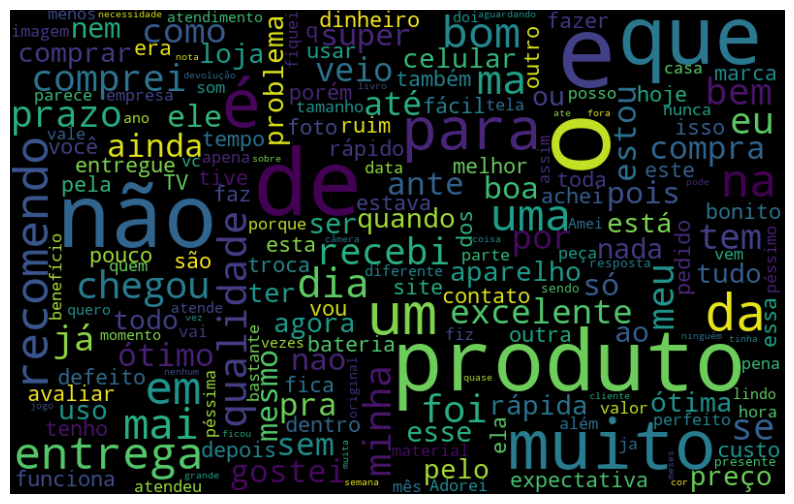

In [57]:
nuvem_palavras = WordCloud(width=800, height=500, max_font_size=110, collocations=False).generate(todas_palavras)
plt.figure(figsize=(10,7))
plt.imshow(nuvem_palavras, interpolation='bilinear')
plt.axis('off')
plt.show()

In [59]:
def nuvem_palavras(texto, coluna_texto, sentimento):
  # Filtrando as resenhas com base no sentimento especificado
  texto_sentimento = texto.query(f"sentimento == '{sentimento}'")[coluna_texto]

  # Unindo todas as resenhas em uma única string
  texto_unido = ' '.join(texto_sentimento)

  # Criando e exibindo a nuvem de palavras
  nuvem_palavras = WordCloud(width=800, height=500, max_font_size=110, collocations=False).generate(texto_unido)
  plt.figure(figsize=(10,7))
  plt.imshow(nuvem_palavras, interpolation='bilinear')
  plt.axis('off')
  plt.show()

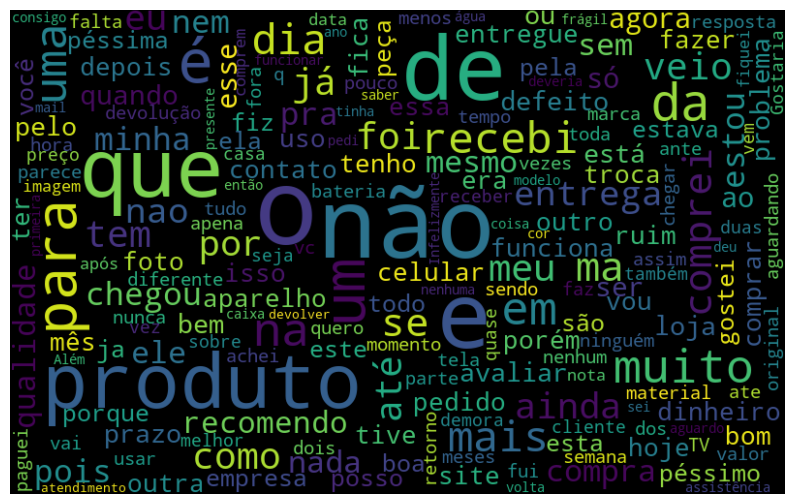

In [60]:
nuvem_palavras(df, 'avaliacao', 'negativo')

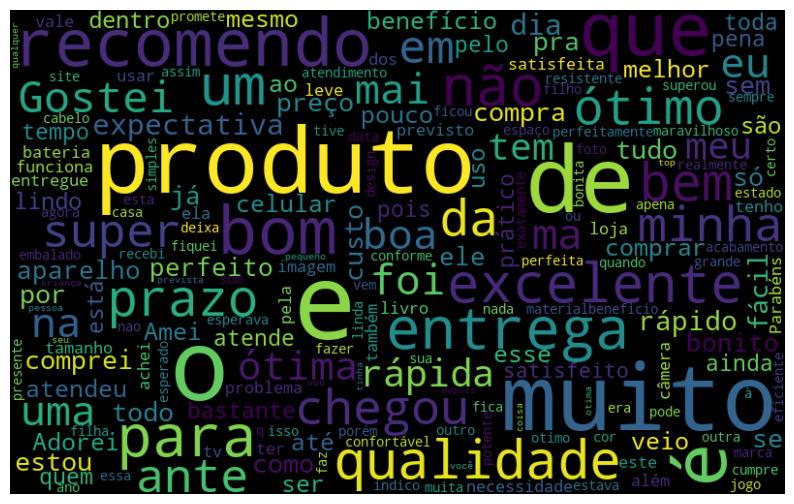

In [61]:
nuvem_palavras(df, 'avaliacao', 'positivo')